In [ ]:
library(tidyverse)
library(limma)

# import plot functions
source("../../../../evaluation_utils/plots/eda_plots.R")
source("../../../../evaluation_utils/filtering/filtering_normalization.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Read data

In [ ]:
metadata <- read_tsv("./metadata.csv", show_col_types = FALSE) %>%
  mutate(Condition = factor(Condition, levels = c("Normal", "Tumor")),
         Dataset = as.factor(Dataset))
# sort by Condition
metadata <- metadata[order(metadata$Condition),] %>% as.data.frame()
rownames(metadata) <- metadata$Sample
data <- read_tsv("./report.csv", show_col_types = FALSE) %>%
  column_to_rownames(var = "Gene Symbol")

data <- data[,metadata$Sample] %>% as.data.frame()

ERROR: Error in read_tsv("./metadata.csv", show_col_types = FALSE) %>% mutate(Condition = factor(Condition, : could not find function "%>%"


In [ ]:
# Filtering
data <- filter_na_proteins(data, metadata, "Sample")
data <- filter_per_center(data, metadata, "Sample", c("PXD030344"), "Dataset")

Filtering out features that have NAs in all columns
	Before filtering: 16912 464 
	After filtering: 16912 464 
Filtering by Dataset  -  2  not-NA per  Dataset 
	Before filtering: 16912 464 
	After filtering: 15449 464 


In [ ]:
data <- medianNorm(data)

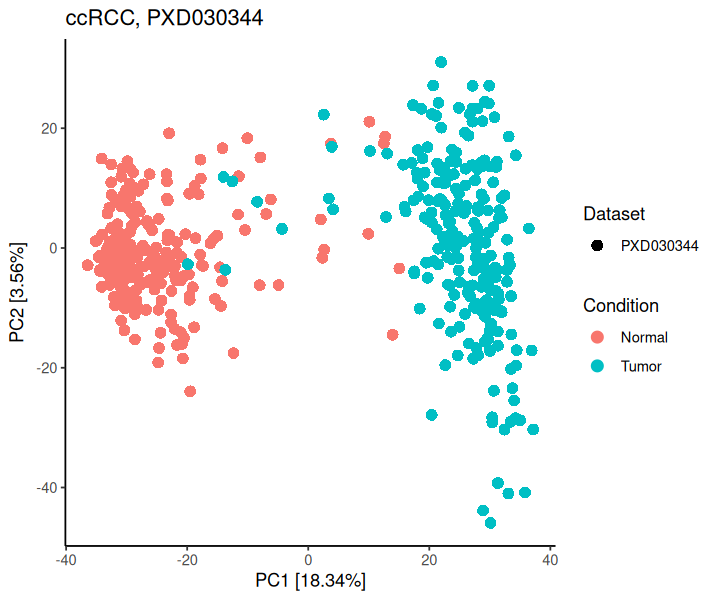

In [ ]:
plot_pca <- pca_plot(log2(data+1), metadata, 
    title="ccRCC, PXD030344", quantitative_col_name='Sample', 
    col_col='Condition', shape_col='Dataset')

options(repr.plot.width=6, repr.plot.height=5)
plot_pca 

Warning message:
“Removed 2907991 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2907991 rows containing non-finite outside the scale range
(`stat_summary()`).”


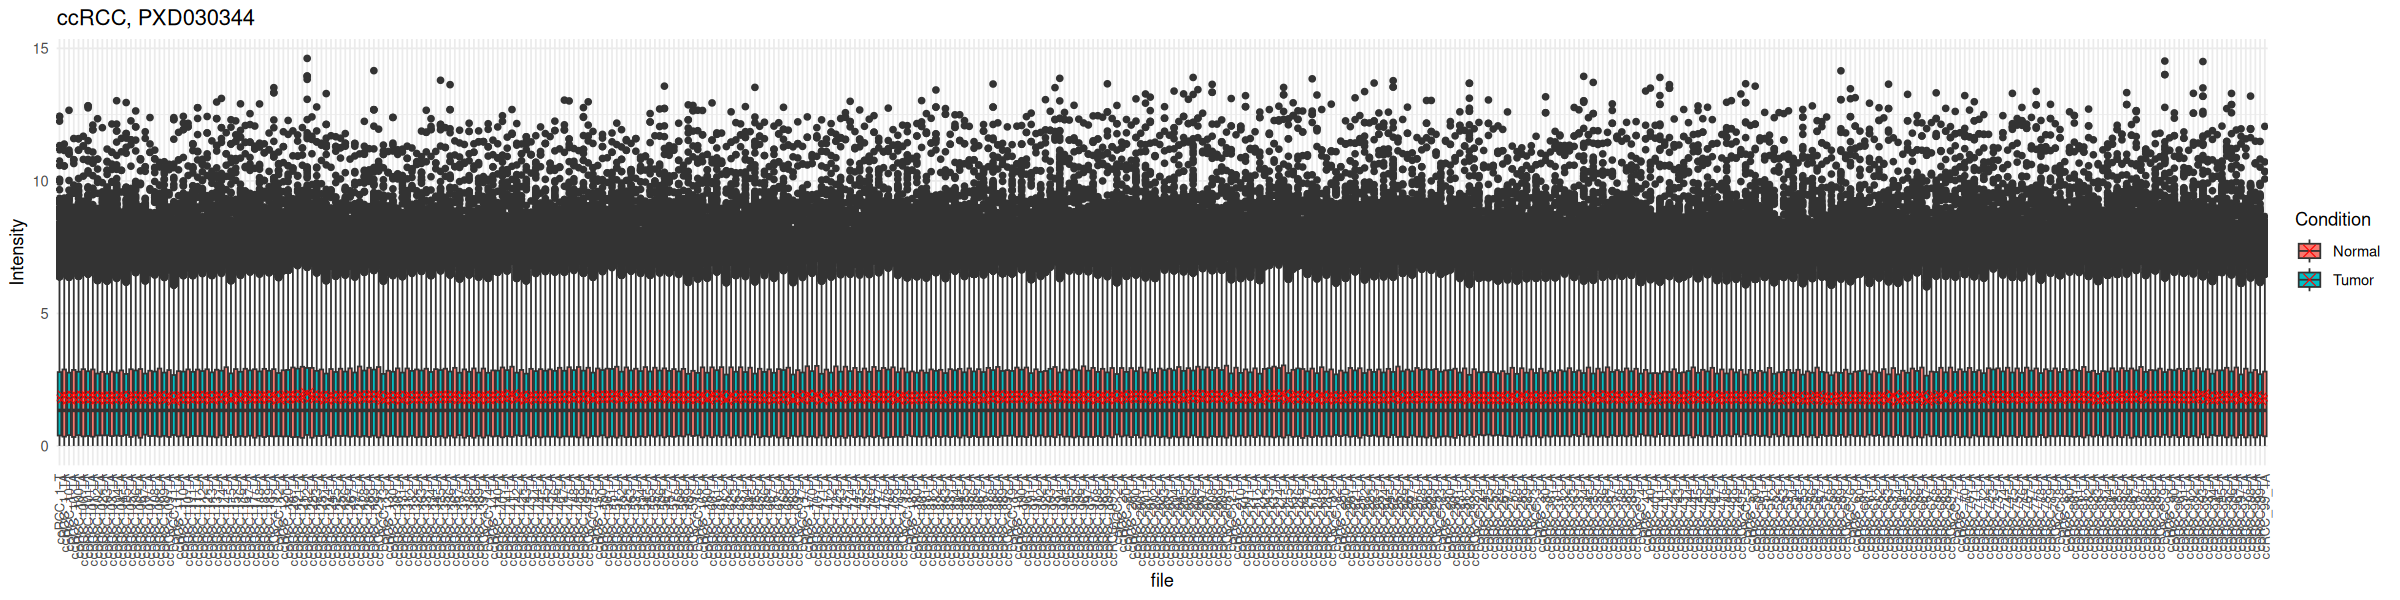

In [ ]:
plot_box <- boxplot_pg(log2(data+1), metadata, 
  'Sample', 'Condition',
  "ccRCC, PXD030344")


options(repr.plot.width=20, repr.plot.height=5)  
plot_box

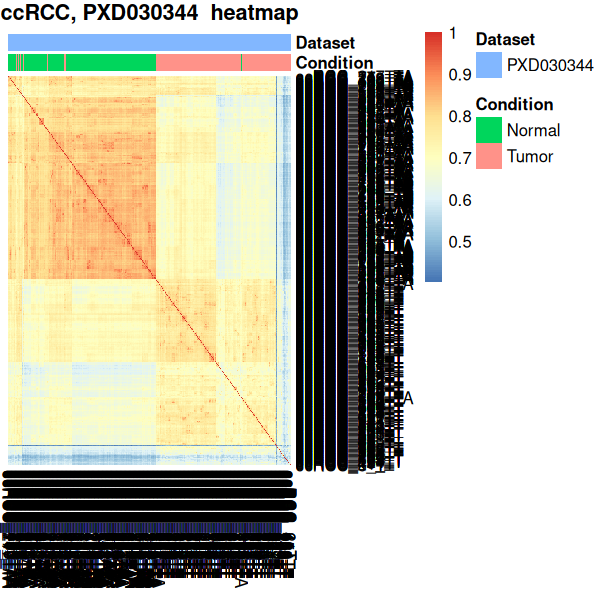

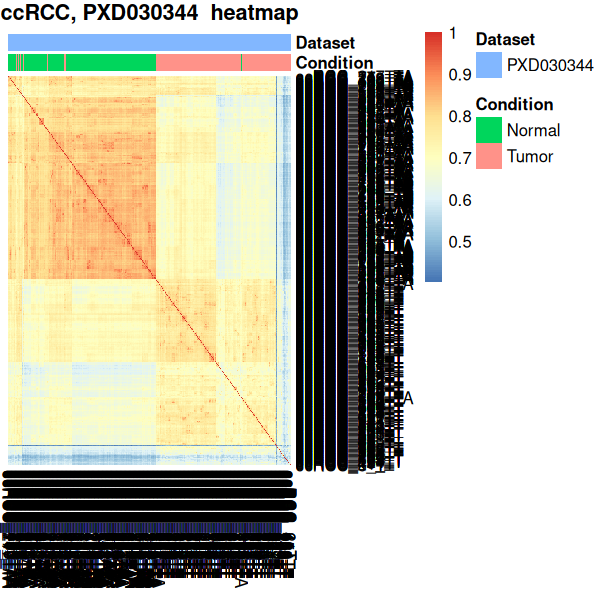

In [ ]:
options(repr.plot.width=5, repr.plot.height=5)
plot_heat <- heatmap_plot(
    log2(data+1), metadata, 
  "ccRCC, PXD030344 ", condition="Condition", lab="Dataset")


In [ ]:
# save to file report to csv
write.csv(
    log2(data+1) %>% rownames_to_column("Gene"), 
    file = "./report_filtered.csv",
    row.names = FALSE
)

In [ ]:
# all versions of all used packages print
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 24.04.1 LTS

Matrix products: default
BLAS/LAPACK: /home/yuliya/miniforge3/envs/FedProt/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] foreach_1.5.2     data.table_1.16.4 patchwork_1.3.0   gridExtra_2.3    
 [5] limma_3.58.1      lubridate_1.9.4   forcats_1.0.0     stringr_1.5.1    
 [9] dplyr_1.1.4       purrr_1.0.2       readr_2.1.5   